In [1]:
import os
os.chdir("../")
os.getcwd()

'/home/minh_khai/salinity/ai-agent-learning/quick-ai-agent-test'

#### First Example

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class EmployeeState(TypedDict):
    employee_name:  str
    monthly_salary: int
    working_days:   int
    completed_projects: int

    yearly_salary:  int
    bonus_amount:   int
    project_status: str
    summary:        str

## Defining Nodes

In [3]:
# Node 1: Calculate yearly salary
def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = state['monthly_salary'] * 12
    
    return {'yearly_salary': yearly_salary}

In [4]:
# Node 2: Calculate bonus amount
def calculate_bonus_amount(state: EmployeeState):
    bonus_amount = state['monthly_salary'] * 2
    
    return {'bonus_amount': bonus_amount}

In [5]:
# Node 3: Project Evaluation
def evaluate_project(state: EmployeeState):
    project_status = 'Excellent' if state['completed_projects'] >= 10 else 'Average'
    
    return {'project_status': project_status}

In [6]:
# Node 4: Summary
def generate_summary(state: EmployeeState):
    summary  = f"Employee: {state['employee_name']}; "
    summary += f"Monthly Salary: {state['monthly_salary']}; "
    summary += f"Working Days: {state['working_days']}; "
    summary += f"Completed Projects: {state['completed_projects']}; "
    summary += f"Yearly Salary: {state['yearly_salary']}; "
    summary += f"Bonus Amount: {state['bonus_amount']}; "
    summary += f"Project Status: {state['project_status']}; "
    
    return {'summary': summary}

In [7]:
# Defining Graph
graph = StateGraph(EmployeeState)

# Step1: Add nodes
graph.add_node('calculate_yearly_salary', calculate_yearly_salary)
graph.add_node('calculate_bonus', calculate_bonus_amount)
graph.add_node('project_evaluation', evaluate_project)
graph.add_node('summary', generate_summary)

# Step2: Add edges
graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'project_evaluation')

graph.add_edge('calculate_yearly_salary', 'summary')
graph.add_edge('calculate_bonus', 'summary')
graph.add_edge('project_evaluation', 'summary')

graph.add_edge('summary', END)

#       ->  calculate_yearly_salary   ->
# START -> calculate_bonus_amount     -> summary -> END
#       -> project_evaluation         ->  

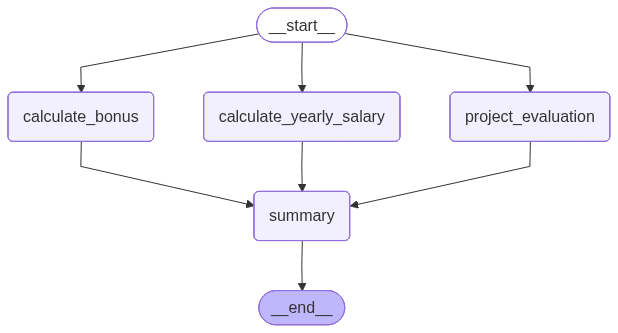

In [8]:
workflow = graph.compile()
workflow

### Inference

In [ ]:
initial_state = {
    'employee_name': 'Mkhue',
    'monthly_salary': 000000,
    'working_days':   0,
    'completed_projects': 7,
    "married":      False
}

result = workflow.invoke(initial_state)

In [12]:
result

{'employee_name': 'Mkhue',
 'monthly_salary': 0,
 'working_days': 0,
 'completed_projects': 7,
 'yearly_salary': 0,
 'bonus_amount': 0,
 'project_status': 'Average',
 'summary': 'Employee: Mkhue; Monthly Salary: 0; Working Days: 0; Completed Projects: 7; Yearly Salary: 0; Bonus Amount: 0; Project Status: Average; '}

#### Second Example

In [ ]:
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

class EssayState(TypedDict):
    essay: str
    language_feedback:  str
    analysis_feedback:  str
    clarity_feedback:   str
    overall_feedback:   str
    
    individual_scores:  Annotated[list[int], operator.add]
    avg_score: float

class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay")
    score:    int = Field(description="Score out of 10", ge=0, le=10)

In [14]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_anthropic import ChatAnthropic

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

structured_model = llm.with_structured_output(EvaluationSchema)

In [19]:
def evaluate_language(state: EssayState):
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)
    
    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: EssayState):
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)
    
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: EssayState):
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)
    
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: EssayState):
    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = llm.invoke(prompt).content
    
    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    
    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [20]:
graph = StateGraph(EssayState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')


graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

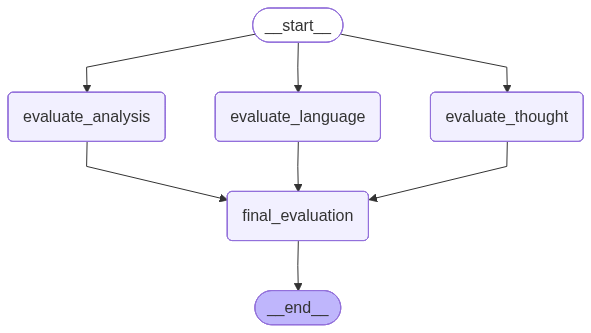

In [21]:
workflow = graph.compile()
workflow

In [24]:
essay = """The United States in the Age of AI: The Infrastructure and Capital Superpower

As of 2026, the United States is the focal point of the AI revolution, characterized by significant investment and rapid commercialization. 

The transition from software-centric AI to "Agentic AI" and "Physical AI" has redefined corporate operating models towards human-machine collaboration. 

However, this rapid expansion faces challenges, notably an energy crisis, as AI data centers require immense power, leading to a "Bring Your Own Power" movement and direct federal action on energy supply. 

The government is aggressively promoting AI innovation to maintain a competitive edge, particularly against China, with defense spending reaching tens of billions. 

Yet, local communities are experiencing tension over the environmental impacts of data centers and increased utility demands. 

The U.S. stands at a critical juncture, balancing technological advancement with physical limitations in infrastructure necessary for future growth."""


intial_state = {
    'essay': essay
}

result = workflow.invoke(intial_state)
result

{'essay': 'The United States in the Age of AI: The Infrastructure and Capital Superpower\n\nAs of 2026, the United States is the focal point of the AI revolution, characterized by significant investment and rapid commercialization. \n\nThe transition from software-centric AI to "Agentic AI" and "Physical AI" has redefined corporate operating models towards human-machine collaboration. \n\nHowever, this rapid expansion faces challenges, notably an energy crisis, as AI data centers require immense power, leading to a "Bring Your Own Power" movement and direct federal action on energy supply. \n\nThe government is aggressively promoting AI innovation to maintain a competitive edge, particularly against China, with defense spending reaching tens of billions. \n\nYet, local communities are experiencing tension over the environmental impacts of data centers and increased utility demands. \n\nThe U.S. stands at a critical juncture, balancing technological advancement with physical limitations

#### Third Example

In [33]:
from typing import Annotated, Literal

class SentimentSchema(BaseModel):
    sentiment: Annotated[
        Literal['positive', 'negative'], 
        Field(description='Sentiment of the review')
    ]

class DiagnosisSchema(BaseModel):
    issue_type: Annotated[
        Literal["UX", "Performance", "Bug", "Support", "Other"],
        Field(description="Category of issue")
    ]
    tone: Annotated[
        Literal["angry", "frustrated", "disappointed", "calm"],
        Field(description="Emotional tone")
    ]
    urgency: Annotated[
        Literal["low", "medium", "high"],
        Field(description="How urgent the issue is")
    ]

class ReviewState(TypedDict):
    review:     str
    sentiment:  Literal["positive", "negative"]
    diagnosis:  dict
    response:   str

In [34]:
structure_m1 = llm.with_structured_output(SentimentSchema)
structure_m2 = llm.with_structured_output(DiagnosisSchema)

In [40]:
def find_sentiment(state: ReviewState):
    prompt = f"Sentiment of the review: {state['review']}"
    sentiment = structure_m1.invoke(prompt).sentiment
    
    return {'sentiment': sentiment}

def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
                \n\n\"{state['review']}\"\n
            Also, kindly ask the user to leave feedback on our website."""
    response = llm.invoke(prompt).content
    
    return {'response': response}

def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}
                "Return issue_type, tone, and urgency.
            """
    response = structure_m2.invoke(prompt)
    
    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    
    prompt = f"""You are a support assistant.
            The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', 
            and marked urgency as '{diagnosis['urgency']}'.
            Write an empathetic, helpful resolution message.
            """
    response = llm.invoke(prompt).content
    
    return {'response': response}

def check_sentiment(state: ReviewState) -> Literal['positive', 'negative']:
    return state['sentiment']

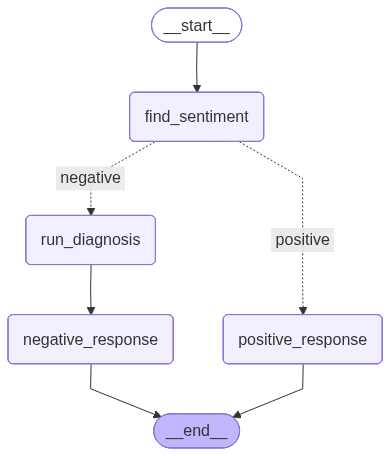

In [41]:
graph = StateGraph(ReviewState)

# add nodes
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# add edges with conditions
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges(
    'find_sentiment', 
    check_sentiment, 
    {"positive": "positive_response", "negative": "run_diagnosis"}
)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()
workflow

In [42]:
intial_state={
    'review': "Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!"
}
result = workflow.invoke(intial_state)
result

{'review': 'Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!',
 'sentiment': 'positive',
 'response': "# Thank You!\n\nThank you so much for taking the time to share such wonderful feedback! We're thrilled to hear that our software has made a positive impact on your workflow and helped save your team valuable time. Your kind words mean the world to us and truly motivate our team to keep innovating and improving.\n\nWe're committed to maintaining the clean, intuitive experience you've come to expect, and we're grateful for customers like you who trust us with your needs.\n\n**We'd love to hear more!** If you have a moment, would you consider sharing your experience on our website as well? Your detailed feedback there helps other potential users make informed decisions and helps us continue to grow and serve our community better.\n\nThan

In [43]:
intial_state={
    'review': "The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement."
}
result = workflow.invoke(intial_state)
result

{'review': 'The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'frustrated',
  'urgency': 'high'},
 'response': "# Hi there,\n\nThank you for reaching out, and I'm sorry you're experiencing performance issues. I can understand how frustrating that must be, especially when you need things to run smoothly.\n\nI'm here to help you get this resolved as quickly as possible. To best assist you, could you please share a few details:\n\n- **What specific performance problems are you seeing?** (e.g., slow loading, freezing, crashes)\n- **When did this start?**\n- **Which device/browser are you using?**\n\nIn the meantime, here are a few quick things you can try:\n- Clear your browser cache and cookies\n- Try a different browser or device\n- Check 